# Probability Distributions and Random Variables

In the previous lectures, probabilities were assigned directly to events in a probability space $(\Omega,\mathcal F,P)$. In practice, however, we are often interested in numerical quantities associated with the outcomes of an experiment, such as the number of heads obtained when tossing a coin several times, the number of customers arriving at a store during one hour, or the height of a randomly selected individual.

Such quantities are modeled by **random variables**. To study them, we first introduce probability distributions on the real line.

## Borel $\sigma$-Algebra

The **Borel $\sigma$-algebra** on $\mathbb R$, denoted by $\mathcal B(\mathbb R)$, is the smallest $\sigma$-algebra containing all open subsets of $\mathbb R$.

Elements of $\mathcal B(\mathbb R)$ are called **Borel sets**. In particular, every open interval, closed interval, half-open interval, countable union, countable intersection, and complement of such sets belongs to $\mathcal B(\mathbb R)$.

## Measurable Functions and Random Variables

Let $(\Omega,\mathcal F)$ and $(\mathbb R,\mathcal B(\mathbb R))$ be measurable spaces. A function

$$
\xi:\Omega\to\mathbb R
$$

is called **measurable** if

$$
\xi^{-1}(B)
=
\{\omega\in\Omega:\xi(\omega)\in B\}
\in\mathcal F
\qquad
\forall B\in\mathcal B(\mathbb R).
$$

A **random variable** on a probability space $(\Omega,\mathcal F,P)$ is simply a measurable function $\xi:\Omega\to\mathbb R$.

We denote by

$$
X_\xi=\{\xi(\omega):\omega\in\Omega\}
$$

the set of all possible values of $\xi$.

If $X_\xi$ is finite or countable, then $\xi$ is called a **discrete random variable**.

<p align="center">
<img src="images/rv.png" width="400">
</p>

## Probability Distributions

A **probability distribution** is any probability measure on $(\mathbb R,\mathcal B(\mathbb R))$.

That is,

$$
P:\mathcal B(\mathbb R)\to[0,1].
$$

If there exists a finite or countable set $X\subseteq\mathbb R$ such that $P(X)=1$, then $P$ is called a **discrete probability distribution**.

## Distribution of a Random Variable

Let $\xi$ be a random variable on $(\Omega,\mathcal F,P)$.

The **probability distribution of $\xi$** is the probability measure $P_\xi$ on $(\mathbb R,\mathcal B(\mathbb R))$ defined by

$$
P_\xi(B)
=
P(\{\omega\in\Omega:\xi(\omega)\in B\})
=
P(\xi\in B),
\qquad
B\in\mathcal B(\mathbb R).
$$

Thus, the distribution of a random variable completely describes the probabilities of all events involving its values.

## Probability Mass Function (PMF)

Let $\xi$ be a discrete random variable and let $X_\xi=\{x_1,x_2,\ldots\}$.

The **probability mass function** (PMF) of $\xi$ is the function

$$
p_\xi:\mathbb R\to[0,1]
$$

defined by

$$
p_\xi(x_k)
=
P(\xi=x_k),
\qquad
x_k\in X_\xi,
$$

and $ p_\xi(x)=0$,  $x\notin X_\xi$

The PMF completely determines the distribution of a discrete random variable and satisfies $\sum_{x\in X_\xi} p_\xi(x)=1$.

# Examples of Discrete Probability Distributions

## Uniform Distribution

Let $X$ be a finite set. The uniform distribution on $X$ is defined by

$$
P(x)=\frac1{|X|},
\qquad
x\in X.
$$

## Bernoulli Distribution

For $p\in(0,1)$, $X=\{0,1\}$, and

$$
P(0)=1-p,
\qquad
P(1)=p.
$$

We write

$$
\xi\sim\operatorname{Ber}(p).
$$

## Binomial Distribution

For $n\in\mathbb N$ and $p\in(0,1)$, $X=\{0,1,\ldots,n\}$, and

$$
P(k)
=
\binom nk p^k(1-p)^{n-k}.
$$

We write

$$
\xi\sim\operatorname{Bin}(n,p).
$$

## Geometric Distribution

For $p\in(0,1)$, $X=\mathbb N \setminus \{0\}$, and

$$
P(k)
=
(1-p)^{k-1}p,
\qquad
k\ge1.
$$

We write

$$
\xi\sim\operatorname{Geom}(p).
$$

## Poisson Distribution

For $\lambda>0$, $X=\{0,1,2,\ldots\}$, and

$$
P(k)
=
\frac{\lambda^k e^{-\lambda}}{k!}.
$$

We write

$$
\xi\sim\operatorname{Pois}(\lambda).
$$

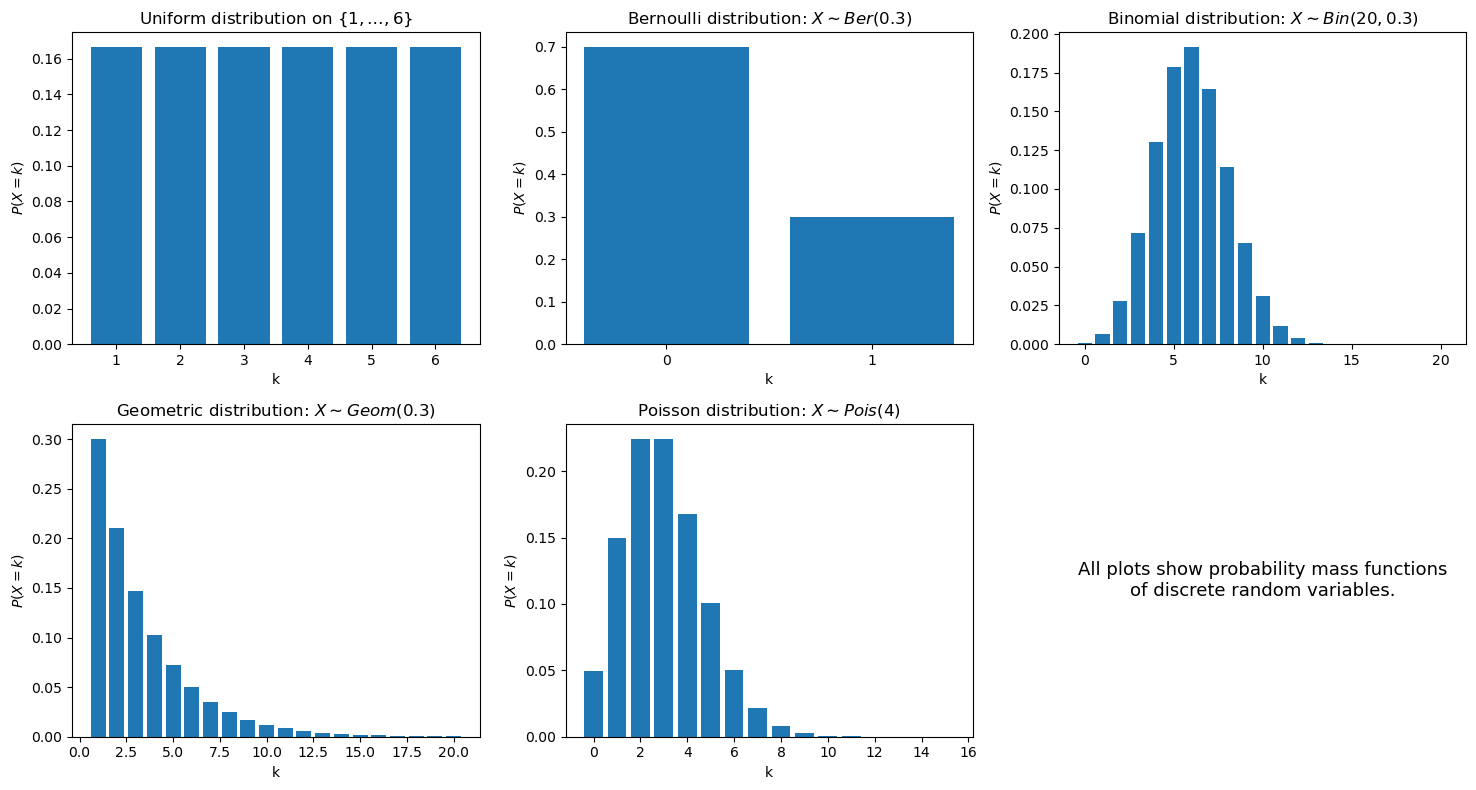

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import comb, factorial, exp

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

# 1. Uniform distribution
X = np.arange(1, 7)
pmf = np.ones(len(X)) / len(X)

axes[0].bar(X, pmf)
axes[0].set_title(r"Uniform distribution on $\{1,\ldots,6\}$")
axes[0].set_xlabel("k")
axes[0].set_ylabel(r"$P(X=k)$")

# 2. Bernoulli distribution
p = 0.3
X = np.array([0, 1])
pmf = np.array([1 - p, p])

axes[1].bar(X, pmf)
axes[1].set_title(r"Bernoulli distribution: $X\sim Ber(0.3)$")
axes[1].set_xlabel("k")
axes[1].set_ylabel(r"$P(X=k)$")
axes[1].set_xticks([0, 1])

# 3. Binomial distribution
n, p = 20, 0.3
X = np.arange(n + 1)
pmf = np.array([comb(n, k) * p**k * (1-p)**(n-k) for k in X])

axes[2].bar(X, pmf)
axes[2].set_title(r"Binomial distribution: $X\sim Bin(20,0.3)$")
axes[2].set_xlabel("k")
axes[2].set_ylabel(r"$P(X=k)$")

# 4. Geometric distribution
p = 0.3
X = np.arange(1, 21)
pmf = np.array([(1-p)**(k-1) * p for k in X])

axes[3].bar(X, pmf)
axes[3].set_title(r"Geometric distribution: $X\sim Geom(0.3)$")
axes[3].set_xlabel("k")
axes[3].set_ylabel(r"$P(X=k)$")

# 5. Poisson distribution
lam = 3
X = np.arange(0, 16)
pmf = np.array([lam**k * exp(-lam) / factorial(k) for k in X])

axes[4].bar(X, pmf)
axes[4].set_title(r"Poisson distribution: $X\sim Pois(4)$")
axes[4].set_xlabel("k")
axes[4].set_ylabel(r"$P(X=k)$")

# 6. Empty / optional note
axes[5].axis("off")
axes[5].text(
    0.5, 0.5,
    "All plots show probability mass functions\nof discrete random variables.",
    ha="center",
    va="center",
    fontsize=13
)

plt.tight_layout()
plt.show()

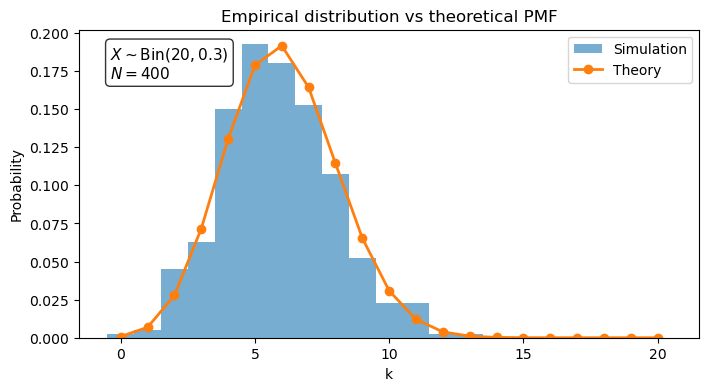

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from math import comb

n, p = 20, 0.3
N = 400

sample = np.random.binomial(n, p, size=N)

x = np.arange(n + 1)
theory = [comb(n, k) * p**k * (1-p)**(n-k) for k in x]

plt.figure(figsize=(8,4))

plt.hist(
    sample,
    bins=np.arange(n+2)-0.5,
    density=True,
    alpha=0.6,
    label="Simulation"
)

plt.plot(
    x,
    theory,
    "o-",
    linewidth=2,
    label="Theory"
)

info = (
    r"$X \sim \mathrm{Bin}(20,0.3)$" "\n"
    rf"$N = {N:,}$"
)

ax = plt.gca()

ax.text(
    0.05,
    0.95,
    rf"$X\sim\mathrm{{Bin}}({n},{p})$" + "\n" + rf"$N={N:,}$",
    transform=ax.transAxes,
    fontsize=11,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.xlabel("k")
plt.ylabel("Probability")
plt.title("Empirical distribution vs theoretical PMF")
plt.legend()
plt.show()

# Poisson Limit Theorem

Let $\xi_n\sim\operatorname{Bin}(n,p_n)$ and suppose that $np_n\to\lambda>0$.

Then for every fixed $k\ge0$,

$$
P(\xi_n=k)
\longrightarrow
\frac{\lambda^k e^{-\lambda}}{k!}.
$$

In other words, the binomial distribution converges to the Poisson distribution when the number of trials becomes large and the success probability becomes small in such a way that the expected number of successes remains approximately constant.

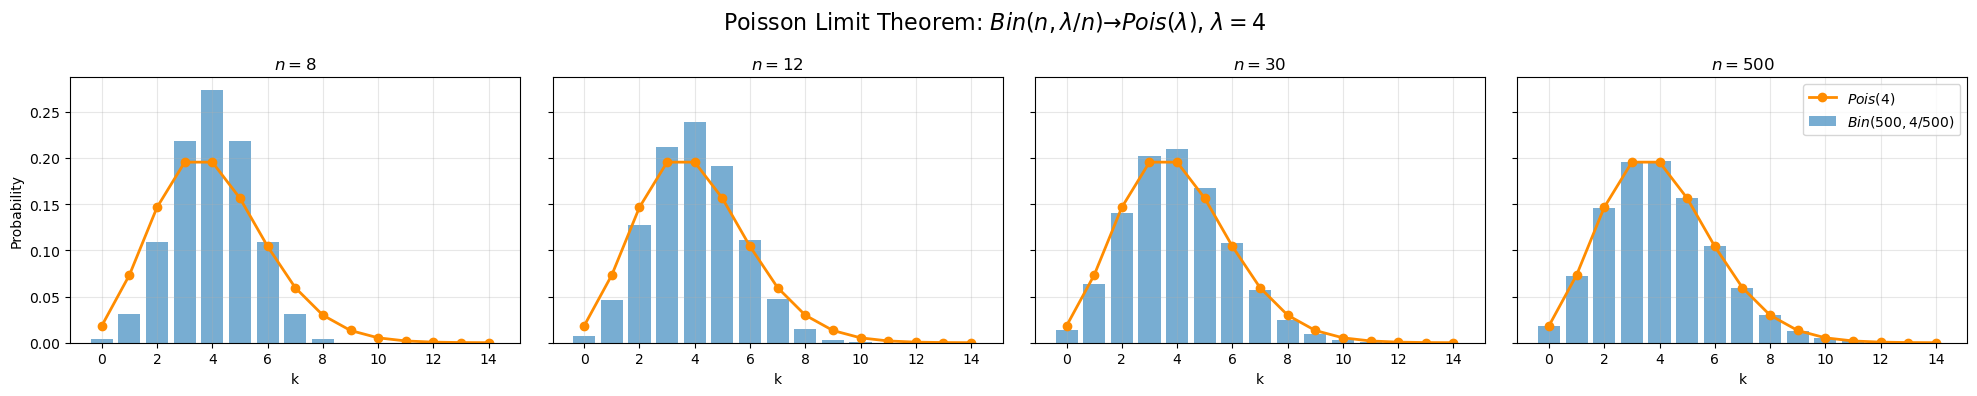

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from math import comb, factorial, exp

lambda_ = 4
ns = [8, 12, 30, 500]
x = np.arange(0, 15)

pois = np.array([
    lambda_**k * exp(-lambda_) / factorial(k)
    for k in x
])

fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=True)

for ax, n in zip(axes, ns):

    p = lambda_ / n

    binom = np.array([
        comb(n, k) * p**k * (1-p)**(n-k)
        for k in x
    ])

    # Binomial distribution (bars)
    ax.bar(
        x,
        binom,
        alpha=0.6,
        label=fr"$Bin({n},{lambda_}/{n})$"
    )

    # Poisson distribution (line)
    ax.plot(
        x,
        pois,
        "o-",
        color="darkorange",
        linewidth=2,
        label=fr"$Pois({lambda_})$"
    )

    ax.set_title(fr"$n={n}$")
    ax.set_xlabel("k")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Probability")

fig.suptitle(
    rf"Poisson Limit Theorem: $Bin(n,\lambda/n)\to Pois(\lambda)$, $\lambda={lambda_}$",
    fontsize=16
)

axes[-1].legend(loc="upper right")

plt.tight_layout()
plt.show()

# Independence of Random Variables

Two discrete random variables $\xi$ and $\eta$ are called **independent** if

$$
P(\xi=x,\eta=y)
=
P(\xi=x)P(\eta=y)
$$

for all possible values $x\in X_\xi$ and $y\in X_\eta$.

Similarly, a collection of random variables $\xi_1,\ldots,\xi_n$ is called mutually independent if

$$
P(\xi_{i_1}=x_{i_1},\ldots,\xi_{i_k}=x_{i_k})
=
\prod_{j=1}^{k}
P(\xi_{i_j}=x_{i_j})
$$

for every subset $\{i_1,\ldots,i_k\}\subseteq\{1,\ldots,n\}$.

## Convolution of Discrete Distributions

Let $\xi$ and $\eta$ be independent discrete random variables. Then

$$
P(\xi+\eta=k)
=
\sum_{i=-\infty}^{+\infty}
P(\xi=i)P(\eta=k-i).
$$

This formula is called the **convolution formula**.

Important examples:

- If $\xi\sim\operatorname{Bin}(n,p)$ and $\eta\sim\operatorname{Bin}(m,p)$ are independent, then

$$
\xi+\eta\sim\operatorname{Bin}(n+m,p).
$$

- If $\xi\sim\operatorname{Pois}(\lambda_1)$ and $\eta\sim\operatorname{Pois}(\lambda_2)$ are independent, then

$$
\xi+\eta\sim\operatorname{Pois}(\lambda_1+\lambda_2).
$$

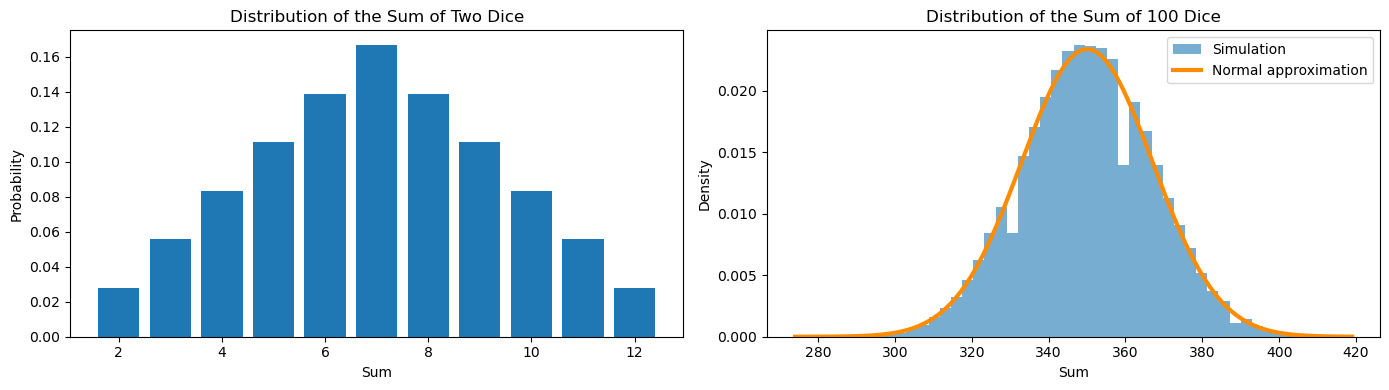

In [53]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# =====================================================
# Sum of 2 dice (exact distribution)
# =====================================================

die = np.ones(6) / 6
conv = np.convolve(die, die)

sums2 = np.arange(2, 13)

# =====================================================
# Sum of 100 dice (simulation)
# =====================================================

N = 100_000

sample100 = np.random.randint(
    1, 7,
    size=(N, 100)
).sum(axis=1)

# =====================================================
# Normal approximation
# =====================================================

mu = 100 * 3.5
sigma = np.sqrt(100 * 35 / 12)

x = np.linspace(
    sample100.min(),
    sample100.max(),
    1000
)

normal_pdf = (
    1 / (sigma * np.sqrt(2 * np.pi))
    * np.exp(-(x - mu) ** 2 / (2 * sigma ** 2))
)

# =====================================================
# Plot
# =====================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left panel
axes[0].bar(sums2, conv)
axes[0].set_title("Distribution of the Sum of Two Dice")
axes[0].set_xlabel("Sum")
axes[0].set_ylabel("Probability")

# Right panel
axes[1].hist(
    sample100,
    bins=50,
    density=True,
    alpha=0.6,
    label="Simulation"
)

axes[1].plot(
    x,
    normal_pdf,
    color="darkorange",
    linewidth=3,
    label="Normal approximation"
)

axes[1].set_title("Distribution of the Sum of 100 Dice")
axes[1].set_xlabel("Sum")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.show()

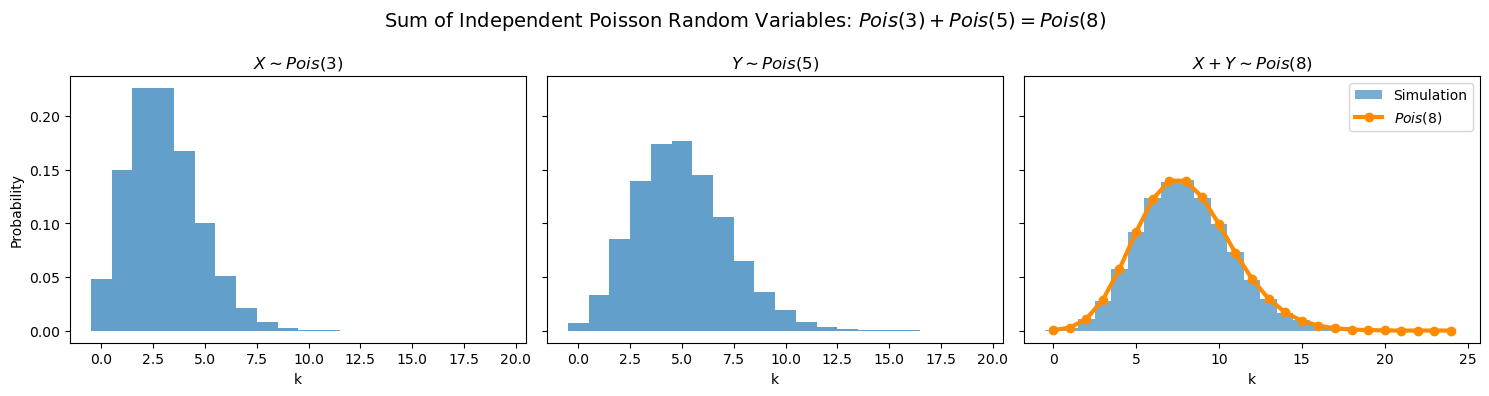

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from math import factorial, exp

np.random.seed(42)

# =====================================================
# Parameters
# =====================================================

lambda1 = 3
lambda2 = 5

N = 100_000

# =====================================================
# Simulation
# =====================================================

X = np.random.poisson(lambda1, size=N)
Y = np.random.poisson(lambda2, size=N)

Z = X + Y

# =====================================================
# Theoretical distribution
# =====================================================

lam = lambda1 + lambda2

k = np.arange(0, 25)

pois_theory = np.array([
    exp(-lam) * lam**i / factorial(i)
    for i in k
])

# =====================================================
# Plot
# =====================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

# X ~ Pois(lambda1)

axes[0].hist(
    X,
    bins=np.arange(-0.5, 20.5, 1),
    density=True,
    alpha=0.7
)

axes[0].set_title(rf"$X\sim Pois({lambda1})$")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Probability")

# Y ~ Pois(lambda2)

axes[1].hist(
    Y,
    bins=np.arange(-0.5, 20.5, 1),
    density=True,
    alpha=0.7
)

axes[1].set_title(rf"$Y\sim Pois({lambda2})$")
axes[1].set_xlabel("k")

# X + Y

axes[2].hist(
    Z,
    bins=np.arange(-0.5, 25.5, 1),
    density=True,
    alpha=0.6,
    label="Simulation"
)

axes[2].plot(
    k,
    pois_theory,
    "o-",
    color="darkorange",
    linewidth=3,
    markersize=6,
    label=rf"$Pois({lam})$"
)

axes[2].set_title(
    rf"$X+Y\sim Pois({lam})$"
)

axes[2].set_xlabel("k")
axes[2].legend()

fig.suptitle(
    rf"Sum of Independent Poisson Random Variables: "
    rf"$Pois({lambda1})+Pois({lambda2})=Pois({lam})$",
    fontsize=14
)

plt.tight_layout()
plt.show()

# Discrete Random Vectors

So far we have studied a single random variable $\xi:\Omega\to\mathbb R$. In many applications, however, several random quantities are observed simultaneously. This leads to the notion of a random vector.

## Definition

A **2-dimensional discrete random vector** is a pair of discrete random variables

$$
(\xi,\eta).
$$

More generally,

$$
(\xi_1,\xi_2,\dots,\xi_n).
$$

For every outcome $\omega\in\Omega$, the random vector assigns a point

$$
(\xi_1(\omega),\xi_2(\omega),\dots,\xi_n(\omega))
\in\mathbb R^n.
$$

The set of all possible values is called the **support** of the random vector.

## Joint Probability Mass Function

The probability distribution of a discrete random vector is described by its **joint probability mass function (joint PMF)**.

### Definition

For a discrete random vector $(\xi,\eta)$,

$$
p_{\xi,\eta}(x,y)
=
\mathbb P(\xi=x,\eta=y).
$$

The value $p_{\xi,\eta}(x,y)$ is the probability that both events occur simultaneously.

The joint PMF satisfies $p_{\xi,\eta}(x,y)\ge0$, and

$$
\sum_x\sum_y p_{\xi,\eta}(x,y)=1.
$$

## Joint PMF Tables

A convenient way to represent a joint PMF is by a table.

### Example: Two Fair Dice

For two independent fair dice,

$$
p_{\xi,\eta}(x,y)=\frac1{36},
\qquad
x,y\in\{1,\dots,6\}.
$$

$$
\begin{array}{c|cccccc}
\xi\backslash\eta
&1&2&3&4&5&6\\
\hline
1&\frac1{36}&\frac1{36}&\frac1{36}&\frac1{36}&\frac1{36}&\frac1{36}\\
2&\frac1{36}&\frac1{36}&\frac1{36}&\frac1{36}&\frac1{36}&\frac1{36}\\
3&\frac1{36}&\frac1{36}&\frac1{36}&\frac1{36}&\frac1{36}&\frac1{36}\\
4&\frac1{36}&\frac1{36}&\frac1{36}&\frac1{36}&\frac1{36}&\frac1{36}\\
5&\frac1{36}&\frac1{36}&\frac1{36}&\frac1{36}&\frac1{36}&\frac1{36}\\
6&\frac1{36}&\frac1{36}&\frac1{36}&\frac1{36}&\frac1{36}&\frac1{36}
\end{array}
$$

Every cell corresponds to one outcome $(x,y)$.

The sum of all entries of the table must be equal to $1$.

# Marginal Distributions

The distributions of $\xi$ and $\eta$ can be recovered from the joint PMF.

## Definition

The **marginal PMF** of $\xi$ is

$$
p_\xi(x)
=
\sum_y p_{\xi,\eta}(x,y).
$$

Similarly,

$$
p_\eta(y)
=
\sum_x p_{\xi,\eta}(x,y).
$$

In words, we sum over all possible values of the other variable.

### Example

For two fair dice,

$$
p_\xi(x)
=
\sum_{y=1}^{6}\frac1{36}
=
\frac16.
$$


## Independence

The notion of independence extends naturally to random vectors.

### Definition

Random variables $\xi$ and $\eta$ are **independent** if

$$
p_{\xi,\eta}(x,y)
=
p_\xi(x)p_\eta(y)
\qquad
\forall x,y.
$$

Thus, the probability of a pair of outcomes factors into the product of the marginal probabilities.

# Discrete distributions in ML

## Logistic Regression

Many machine learning problems involve predicting a binary outcome.

Suppose

$$
Y=
\begin{cases}
1,& \text{success},\\
0,& \text{failure}.
\end{cases}
$$

Then

$$
Y\sim Ber(p),
$$

where $p$ is the probability of success. Logistic regression is used when the response variable has only two possible outcomes.

Examples include:

- Will a customer purchase a product?
- Will a student pass an exam?
- Will a patient develop a disease?
- Is an email spam or not spam?
- Will a user click on an advertisement?


In logistic regression, this probability depends on explanatory variables. For example, an online store may use

$$
(x_1,x_2,x_3)
=
(\text{age},\text{income},\text{number of previous purchases})
$$

to predict the probability that a customer makes a purchase.

For a single feature $x$, the model assumes

$$
p(x)
=
\frac{1}{1+e^{-(\beta_0+\beta_1 x)}}.
$$

Thus,

$$
Y\mid x \sim Ber(p(x)).
$$

Logistic regression is one of the most widely used classification methods in machine learning.

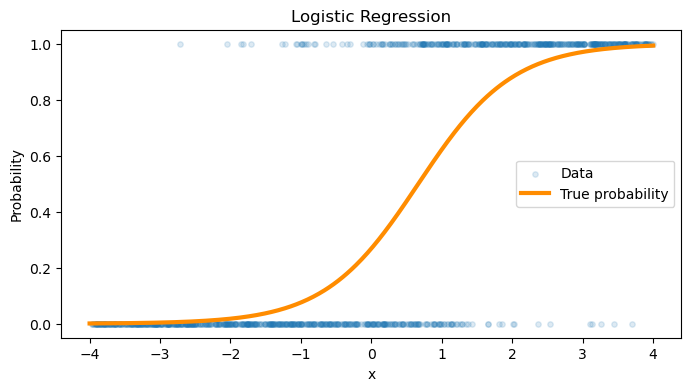

In [65]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

n = 1000

x = np.random.uniform(-4, 4, n)

beta0 = -1
beta1 = 1.5

p = 1 / (1 + np.exp(-(beta0 + beta1 * x)))

y = np.random.binomial(1, p)

x_grid = np.linspace(-4, 4, 500)
p_grid = 1 / (1 + np.exp(-(beta0 + beta1 * x_grid)))

plt.figure(figsize=(8,4))

plt.scatter(
    x,
    y,
    alpha=0.15,
    s=15,
    label="Data"
)

plt.plot(
    x_grid,
    p_grid,
    color="darkorange",
    linewidth=3,
    label="True probability"
)

plt.xlabel("x")
plt.ylabel("Probability")
plt.title("Logistic Regression")
plt.legend()

plt.show()

## Poisson Regression

Many applications involve predicting counts.

Examples include:

- number of website visits;
- number of accidents;
- number of insurance claims;
- number of emails received.

In such situations, it is natural to assume

$$
Y\sim Pois(\lambda),
$$

where $\lambda$ is the expected count.

Poisson regression models the parameter $\lambda$ as

$$
\lambda(x)
=
e^{\beta_0+\beta_1 x}.
$$

The exponential function guarantees that $\lambda(x)>0$.

For example, a company may use

$$
(x_1,x_2,x_3)
=
(\text{advertising budget},
\text{season},
\text{number of users})
$$

to predict the expected number of website visits. Thus,

$$
Y\mid x \sim Pois(\lambda(x)).
$$

Poisson regression is one of the most important generalized linear models.

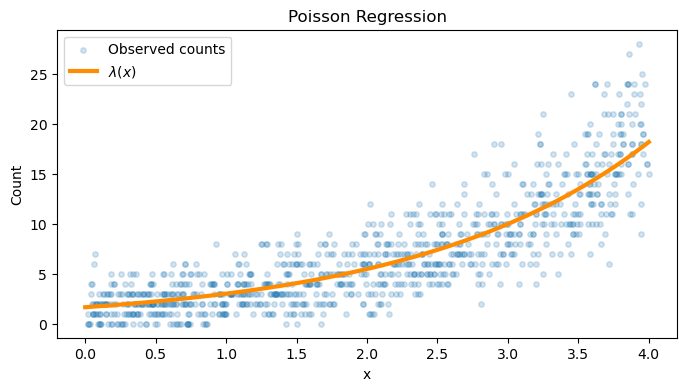

In [66]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

n = 1000

x = np.random.uniform(0, 4, n)

beta0 = 0.5
beta1 = 0.6

lam = np.exp(beta0 + beta1 * x)

y = np.random.poisson(lam)

x_grid = np.linspace(0, 4, 500)
lam_grid = np.exp(beta0 + beta1 * x_grid)

plt.figure(figsize=(8,4))

plt.scatter(
    x,
    y,
    alpha=0.2,
    s=15,
    label="Observed counts"
)

plt.plot(
    x_grid,
    lam_grid,
    color="darkorange",
    linewidth=3,
    label=r"$\lambda(x)$"
)

plt.xlabel("x")
plt.ylabel("Count")
plt.title("Poisson Regression")
plt.legend()

plt.show()